In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import networkx as nx
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy import units as u
import time
import scipy.linalg

In [311]:
basePath = '../data'

In [312]:
fields = ['SubhaloFlag', 'SubhaloGrNr', 'SubhaloMass','SubhaloMassType', 'SubhaloParent', 'SubhaloPos', 'SubhaloLenType', 
          'SubhaloStarMetallicity', 'SubhaloSFR', 'SubhaloGasMetallicity', 'SubhaloGasMetalFractions', 'SubhaloGrNr']
subhalos = il.groupcat.loadSubhalos(basePath,99,fields=fields)

In [313]:
GroupFirstSub = il.groupcat.loadHalos(basePath,99,fields=['GroupFirstSub'])

In [314]:
max(GroupFirstSub)

4371210

In [315]:
# centrals_sum = 0
centrals_flag = np.zeros(len(subhalos['SubhaloGrNr']))

for i, subhalo_group in enumerate(subhalos['SubhaloGrNr']):
    if GroupFirstSub[subhalo_group] == i:
        centrals_flag[i] = 1
        # print(i, subhalo_group)
print(sum(centrals_flag) / len(centrals_flag))

0.7848410886594127


In [316]:
subhalos['centrals_flag'] = centrals_flag

In [317]:
subhalos

{'count': 4371211,
 'SubhaloFlag': array([ True,  True,  True, ...,  True,  True,  True]),
 'SubhaloGrNr': array([      0,       0,       0, ..., 6291318, 6291321, 6291342],
       dtype=int32),
 'SubhaloMass': array([2.7477936e+04, 3.6666228e+03, 7.7345551e+02, ..., 1.5167229e-02,
        1.4661655e-02, 1.4156080e-02], dtype=float32),
 'SubhaloMassType': array([[3.9005981e+03, 2.3325619e+04, 0.0000000e+00, 0.0000000e+00,
         2.5101631e+02, 7.0181096e-01],
        [4.4455853e+02, 3.1840862e+03, 0.0000000e+00, 0.0000000e+00,
         3.7852551e+01, 1.2556633e-01],
        [1.2611633e+01, 7.1818396e+02, 0.0000000e+00, 0.0000000e+00,
         4.2482437e+01, 1.7748705e-01],
        ...,
        [0.0000000e+00, 1.5167229e-02, 0.0000000e+00, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 1.4661655e-02, 0.0000000e+00, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 1.4156080e-02, 0.0000000e+00, 0.0000000e+00,
         0.00000

In [318]:
max(subhalos['SubhaloPos'][:,0]), max(subhalos['SubhaloPos'][:,1]), max(subhalos['SubhaloPos'][:,2])

(74999.98, 75000.04, 75000.0)

In [319]:
subhalos.keys()

dict_keys(['count', 'SubhaloFlag', 'SubhaloGrNr', 'SubhaloMass', 'SubhaloMassType', 'SubhaloParent', 'SubhaloPos', 'SubhaloLenType', 'SubhaloStarMetallicity', 'SubhaloSFR', 'SubhaloGasMetallicity', 'SubhaloGasMetalFractions', 'centrals_flag'])

In [320]:
for i in range(3):
    subhalos['SubhaloPos'][:,i] = ((subhalos['SubhaloPos'][:,i]) * u.kpc).to(u.Mpc)

In [321]:
def impose_cut(subhalos, boolean_array):
    for key in subhalos.keys():
        if key != 'count':
            subhalos[key] = subhalos[key][boolean_array]
        else:
            subhalos[key] = sum(boolean_array)
    return subhalos

In [325]:
# subhalos = impose_cut(subhalos, subhalos['SubhaloMass']*1e10 >=1e9) # subhalo mass > 1e9 Msun
subhalos = impose_cut(subhalos, subhalos['SubhaloMassType'][:,4]*1e10 >=1e9) # subhalo mass > 1e9 Msun
subhalos = impose_cut(subhalos, subhalos['SubhaloFlag'] > 0) # is actually a subhalo
subhalos = impose_cut(subhalos, subhalos['SubhaloLenType'][:,4] > 1000) # more than 100 star particles

In [326]:
sum(subhalos['centrals_flag']) / len(subhalos['centrals_flag'])

0.5832150360570099

In [327]:
subhalos['SubhaloPos'].shape

(17611, 3)

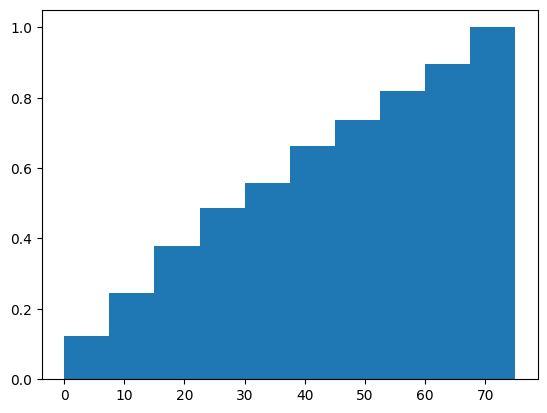

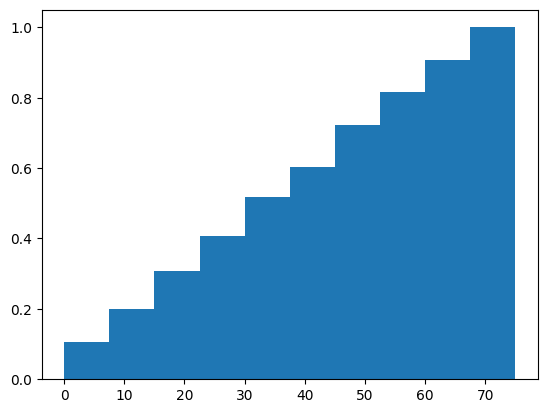

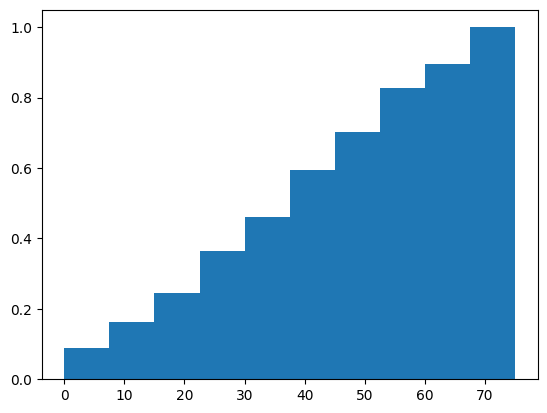

In [328]:
for i in range(3):
    plt.hist(subhalos['SubhaloPos'][:,i], cumulative=True, density=True)
    plt.show()

In [329]:
# limit = 50
# for i in range(3):
#     subhalos = impose_cut(subhalos, subhalos['SubhaloPos'][:,i] < limit)

In [18]:
subhalos['count']

17611

In [19]:
subhalos['SubhaloPos']

array([[ 0.8490915 , 26.326998  , 18.306934  ],
       [ 0.10647334, 24.633324  , 16.900553  ],
       [ 0.8531124 , 26.72575   , 17.510681  ],
       ...,
       [36.158207  , 74.77495   , 70.913055  ],
       [23.255453  , 67.40363   , 73.68266   ],
       [45.46694   , 36.893852  , 72.4918    ]], dtype=float32)

In [20]:
subhalos['SubhaloPos'][:,0]

array([ 0.8490915 ,  0.10647334,  0.8531124 , ..., 36.158207  ,
       23.255453  , 45.46694   ], dtype=float32)

In [21]:
subhalos['centrals_flag']

array([1., 0., 0., ..., 1., 1., 1.])

In [22]:
round(max(subhalos['SubhaloPos'][:,0]))

75

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


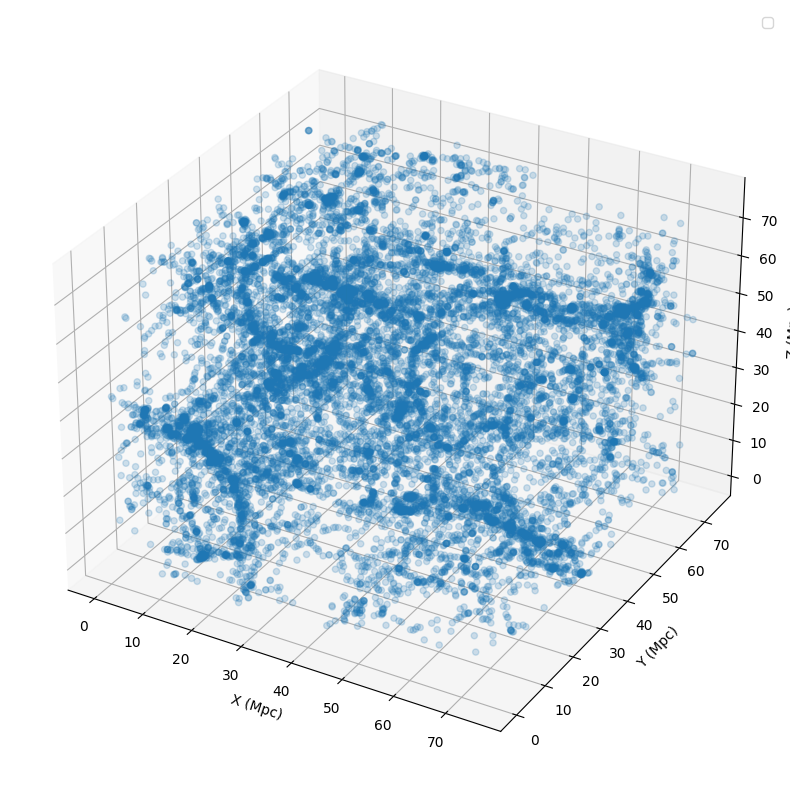

In [38]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.scatter(subhalos['SubhaloPos'][:,0], subhalos['SubhaloPos'][:,1], subhalos['SubhaloPos'][:,2], alpha=0.2)
# ax.scatter(subhalos['SubhaloPos'][subhalos['centrals_flag'] == 1][:,0], subhalos['SubhaloPos'][subhalos['centrals_flag'] == 1][:,1], subhalos['SubhaloPos'][subhalos['centrals_flag'] == 1][:,2], label='centrals', color='red', alpha=0.5)
# ax.scatter(subhalos['SubhaloPos'][subhalos['centrals_flag'] == 0][:,0], subhalos['SubhaloPos'][subhalos['centrals_flag'] == 0][:,1], subhalos['SubhaloPos'][subhalos['centrals_flag'] == 0][:,2], label='satellites', color='blue', alpha=0.5)
ax.legend()
ax.set_xlabel('X (Mpc)')
ax.set_ylabel('Y (Mpc)')
ax.set_zlabel('Z (Mpc)')
plt.show()

In [26]:
def adjust_distances(dist, boxsize):
    if dist > boxsize / 2:
        dist = boxsize - dist
    elif dist <= -boxsize / 2:
        dist = boxsize + dist
    return dist

In [27]:
# Periodic boundary conditions (box size 50)
def periodic_distance_matrix(xs, ys, zs, boxsize):
    points = np.vstack((xs, ys, zs)).T
    num_points = points.shape[0]
    dist_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        delta = points - points[i]
        delta = delta - boxsize * np.round(delta / boxsize)
        dist_matrix[i] = np.sqrt(np.sum(delta**2, axis=1))
        # dx = delta[:,0]
        # dy = delta[:,1]
        # dz = delta[:,2]

        # new_dx = np.array([adjust_distances(d, boxsize) for d in dx])
        # new_dy = np.array([adjust_distances(d, boxsize) for d in dy])
        # new_dz = np.array([adjust_distances(d, boxsize) for d in dz])
        # dist_matrix[i] = np.sqrt(new_dx**2 + new_dy**2 + new_dz**2)
    return dist_matrix

boxsize = round(max(subhalos['SubhaloPos'][:,0]))
print(boxsize)
distance_matrix = periodic_distance_matrix(subhalos['SubhaloPos'][:,0], subhalos['SubhaloPos'][:,1], subhalos['SubhaloPos'][:,2], boxsize)

75


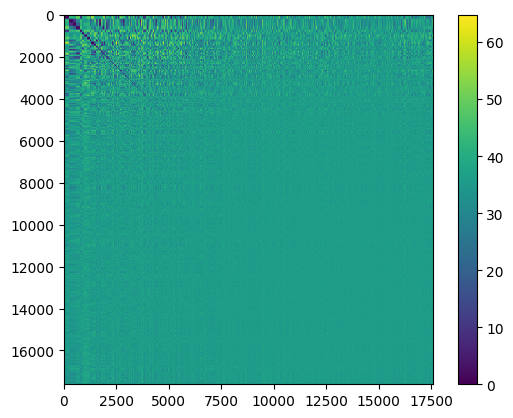

In [28]:
plt.imshow(distance_matrix)
plt.colorbar()
plt.show()

In [29]:
threshold = 5  # Set your desired threshold value

nearest_neighbor_matrix = np.where(distance_matrix < threshold, distance_matrix, 0)

In [30]:
similarity_distances = euclidean_distances(np.sort(nearest_neighbor_matrix, axis=1))
# plt.imshow(similarity_distances)
# plt.colorbar(label='Similarity Distance')
# plt.title('Similarity Distance Matrix')
# plt.show()

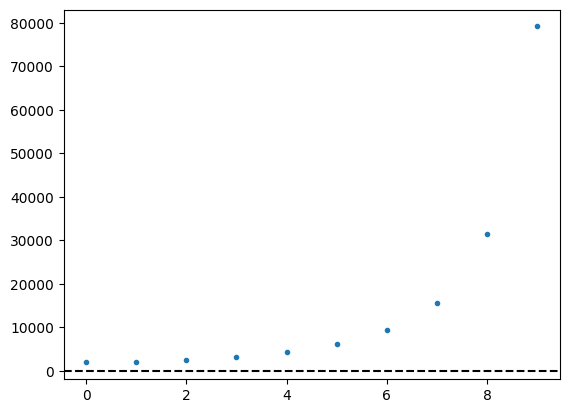

In [31]:
# MDS embedding
from scipy.sparse.linalg import eigsh

D = similarity_distances

num_points = D.shape[0]
C = np.eye(num_points) - (1 / num_points)*np.ones_like(D)
B = -0.5 * np.matmul(C, np.matmul(D, C))
# evals, evecs = np.linalg.eig(B)
evals, evecs = eigsh(B, k=10,which='LA')
plt.plot(evals, '.')
plt.axhline(0, color='k', linestyle='--')

In [35]:
# want them sorted from largest to smallest
order = np.argsort(evals)[::-1]
evals = evals[order]
evecs = evecs[:, order]

In [36]:
# Use only leading positive eigenvalues
# num_positive = np.minimum(np.where(evals < 0)[0][0] - 1, 10)
num_positive = 10

print(np.sum(num_positive))
num_to_keep = max(2, np.sum(num_positive))
print(f"Keeping {num_to_keep} dimensions")
X = evecs[:, :num_to_keep] * np.sqrt(evals[:num_to_keep])

10
Keeping 10 dimensions


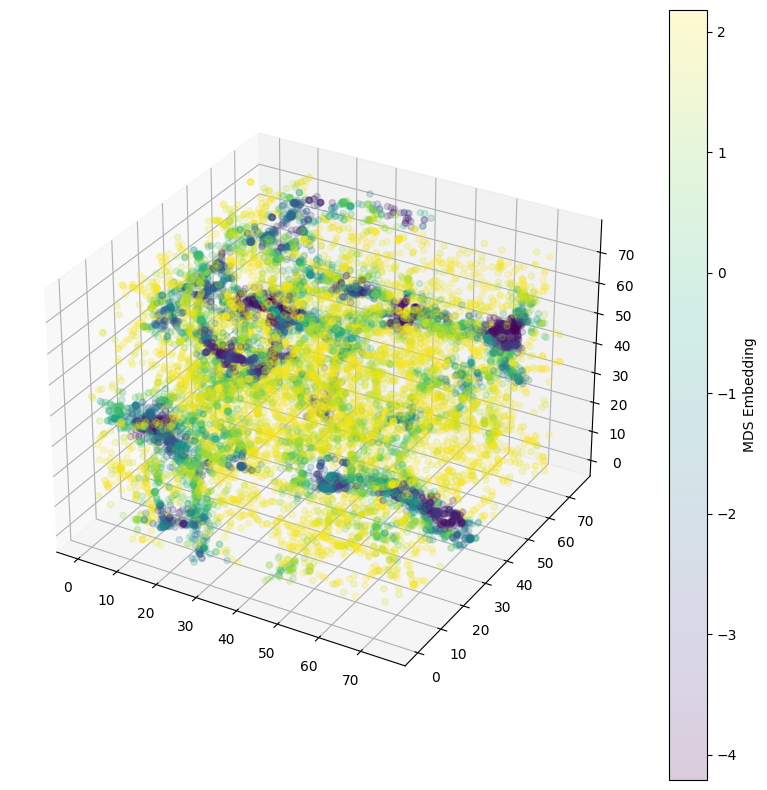

In [44]:
# PCA on Isomap embedding
# pca = PCA(n_components=3)
# embedding = pca.fit_transform(np.real(X))
# # pca.fit(np.real(X.T))

# print("Explained variance ratio:", pca.explained_variance_ratio_)

embedding = X[:, :3]  # Use the first 3 dimensions for visualization
# Visualize embedding
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(subhalos['SubhaloPos'][:,0], subhalos['SubhaloPos'][:,1], subhalos['SubhaloPos'][:,2], c=embedding[:,0], alpha=0.2)
# p = ax.scatter(xs, ys, zs, c=pca.components_[0])

cbar = fig.colorbar(p, ax=ax)
cbar.set_label("MDS Embedding")
plt.show()

In [45]:
import plotly.express as px
fig = px.scatter_3d(x=subhalos['SubhaloPos'][:,0], y=subhalos['SubhaloPos'][:,1], z=subhalos['SubhaloPos'][:,2], color=embedding[:,0])
fig.update_traces(marker=dict(size=4))

fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
# from plotly.offline import plot
# plot(fig, filename='galaxies_300.html', auto_open=True)
fig.show()


(array([2.174e+03, 7.281e+03, 5.112e+03, 2.617e+03, 2.700e+02, 8.100e+01,
        4.300e+01, 2.400e+01, 7.000e+00, 2.000e+00]),
 array([0.00595288, 0.01160004, 0.0172472 , 0.02289436, 0.02854153,
        0.03418869, 0.03983585, 0.04548301, 0.05113017, 0.05677733,
        0.06242449]),
 <BarContainer object of 10 artists>)

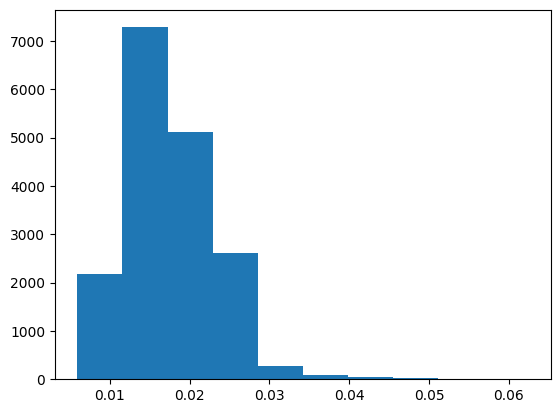

In [175]:
plt.hist(subhalos['SubhaloStarMetallicity'])

In [176]:
min(subhalos['SubhaloStarMetallicity']), max(subhalos['SubhaloStarMetallicity'])

(0.005952881, 0.062424492)

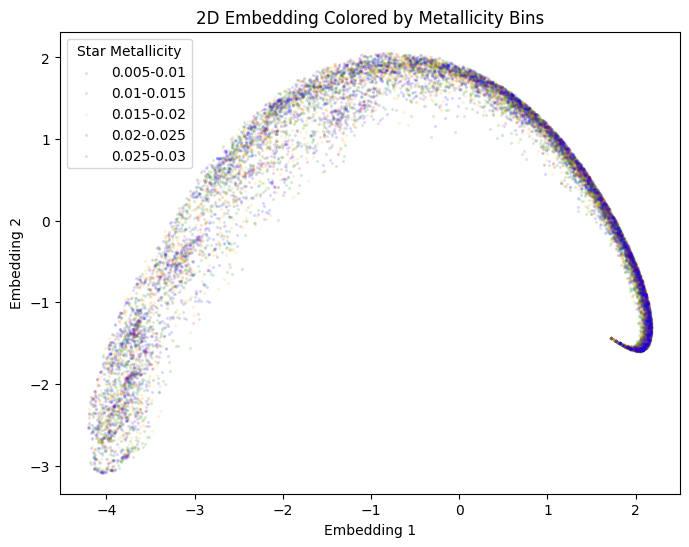

In [200]:
# Define metallicity bins
bins = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
# bins = [0, 0.015, 0.03]
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
metallicity = subhalos['SubhaloStarMetallicity']
bin_indices = np.digitize(metallicity, bins) - 1

colors = ['red', 'green', 'orange', 'blue', 'purple']

plt.figure(figsize=(8,6))
for i, label in enumerate(labels):
    mask = bin_indices == i
    plt.scatter(embedding[mask,0], embedding[mask,1], s=2, color=colors[i], label=labels[i], alpha=0.1)

plt.xlabel("Embedding 1")
plt.ylabel("Embedding 2")
plt.legend(title="Star Metallicity")
plt.title("2D Embedding Colored by Metallicity Bins")
plt.show()

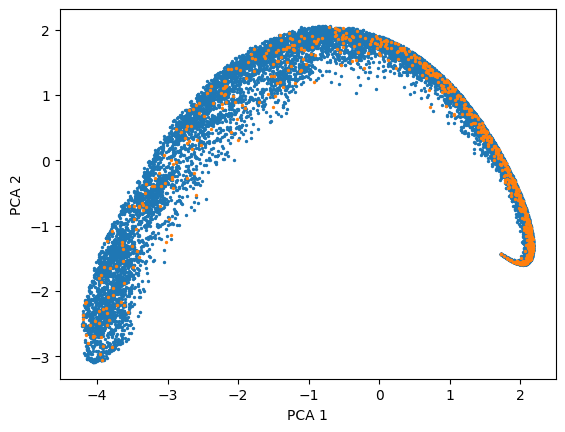

In [193]:
# plt.scatter(embedding[:,0], embedding[:,1], c = subhalos['SubhaloStarMetallicity'], s=2, vmin = 0.01, vmax= 0.025)

mask2 = subhalos['SubhaloStarMetallicity'] > 0.01
plt.scatter(embedding[:,0][mask2], embedding[:,1][mask2], s=2)
mask = subhalos['SubhaloStarMetallicity'] < 0.01
plt.scatter(embedding[:,0][mask], embedding[:,1][mask], s=2)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
# plt.colorbar(label="log star metallicity")
plt.show()

(array([5534., 4081., 3094., 2223., 1633.,  685.,  243.,   82.,   29.,
           7.]),
 array([ 9.00003719,  9.34000397,  9.67996979, 10.01993656, 10.35990334,
        10.69986916, 11.03983593, 11.3798027 , 11.71976948, 12.0597353 ,
        12.39970207]),
 <BarContainer object of 10 artists>)

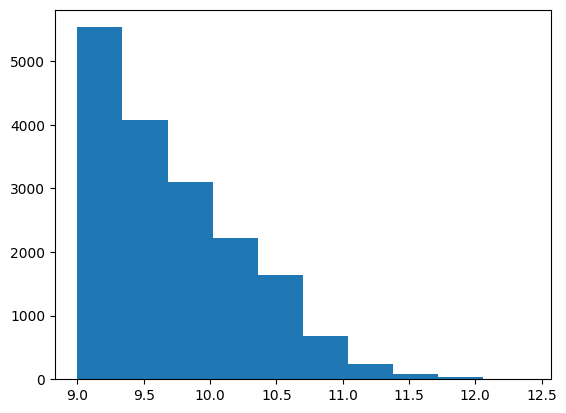

In [55]:
plt.hist(np.log10(subhalos['SubhaloMassType'][:,4]*1e10))

(array([5534., 4081., 3094., 2223., 1633.,  685.,  243.,   82.,   29.,
           7.]),
 array([ 9.00003719,  9.34000397,  9.67996979, 10.01993656, 10.35990334,
        10.69986916, 11.03983593, 11.3798027 , 11.71976948, 12.0597353 ,
        12.39970207]),
 <BarContainer object of 10 artists>)

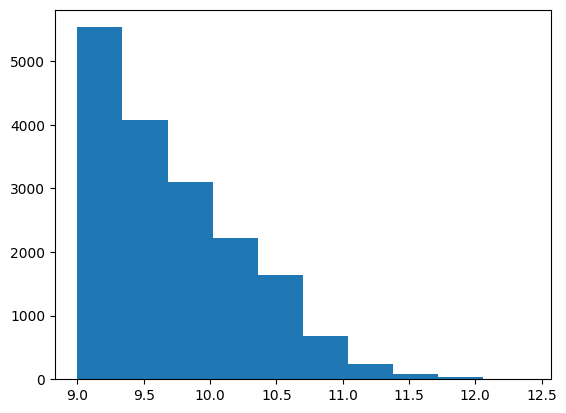

In [164]:
plt.hist(np.log10(subhalos['SubhaloMassType'][:,4]*1e10))

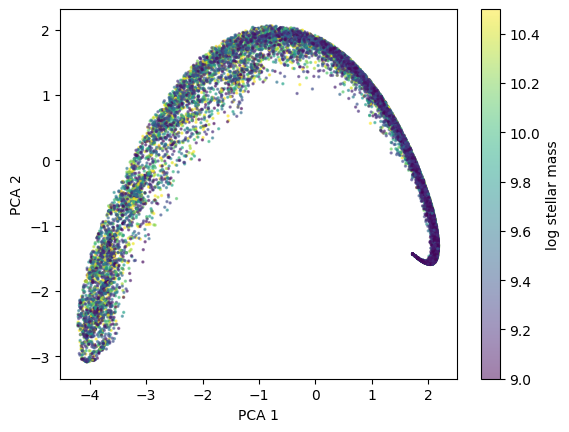

In [166]:
plt.scatter(embedding[:,0], embedding[:,1], c = np.log10(subhalos['SubhaloMassType'][:,4]*1e10), s = 2, vmax=10.5, vmin=9, alpha=0.5)
# plt.scatter(embedding[:,0][np.log10(subhalos['SubhaloMassType'][:,4]*1e10) > 11], embedding[:,1][np.log10(subhalos['SubhaloMassType'][:,4]*1e10) > 11])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log stellar mass")
plt.show()

In [306]:
sum(subhalos['SubhaloGasMetallicity']==0) / len(subhalos['SubhaloGasMetallicity'])

0.15297257395945715

(array([2.174e+03, 7.281e+03, 5.112e+03, 2.617e+03, 2.700e+02, 8.100e+01,
        4.300e+01, 2.400e+01, 7.000e+00, 2.000e+00]),
 array([0.00595288, 0.01160004, 0.0172472 , 0.02289436, 0.02854153,
        0.03418869, 0.03983585, 0.04548301, 0.05113017, 0.05677733,
        0.06242449]),
 <BarContainer object of 10 artists>)

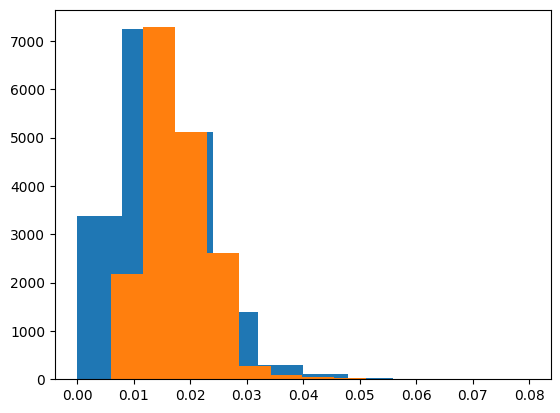

In [308]:
plt.hist(subhalos['SubhaloGasMetallicity'])
plt.hist(subhalos['SubhaloStarMetallicity'])

In [346]:
from scipy.stats import binned_statistic

mask = (subhalos['SubhaloStarMetallicity'] <= 0) & (subhalos['SubhaloStarMetallicity'] >= 0.01)

plt.hist2d(
    embedding[mask, 0],
    subhalos['SubhaloStarMetallicity'][mask],
    bins=50,
    norm=mpl.colors.LogNorm()
)
plt.xlabel("Embedding 1")
plt.ylabel("Star Metallicity")
plt.colorbar(label='Counts')

# Compute running median
x = embedding[mask, 0]
y = subhalos['SubhaloStarMetallicity'][mask]
bin_means, bin_edges, _ = binned_statistic(x, y, statistic='median', bins=50)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, bin_means, color='red', lw=2, label='Running Median')

plt.legend()
plt.show()

bin_means, bin_edges, _ = binned_statistic(x, y, statistic='median', bins=30)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, bin_means, color='red', lw=2, label='Running Median')
plt.xlabel("Embedding (More -> Less clustered)")
plt.ylabel("Star Metallicity")
plt.legend()
plt.show()

ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x119774310> (for post_execute):


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 640x480 with 2 Axes>

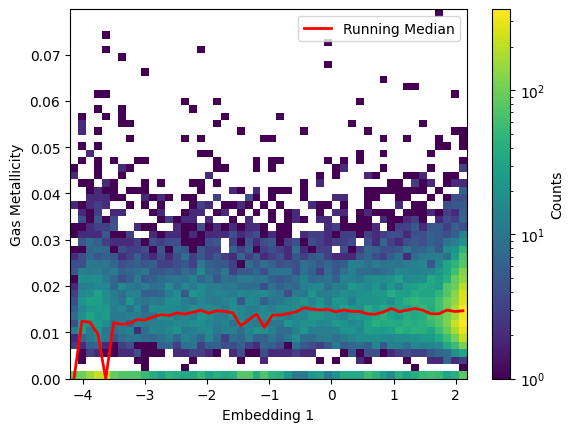

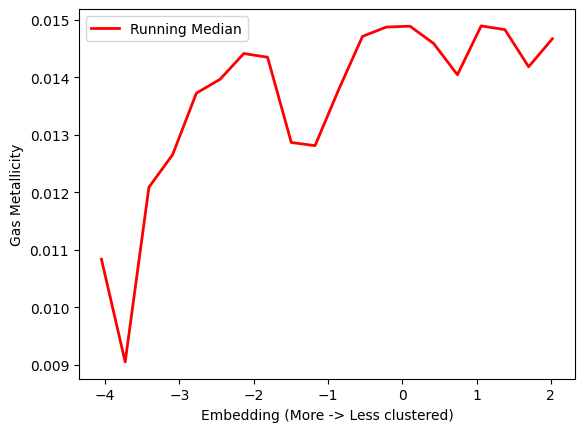

In [386]:
mask = (subhalos['SubhaloGasMetallicity'] <= 0.1) & (subhalos['SubhaloGasMetallicity'] >= 0)

plt.hist2d(
    embedding[mask, 0],
    subhalos['SubhaloGasMetallicity'][mask],
    bins=50,
    norm=mpl.colors.LogNorm()
)
plt.xlabel("Embedding 1")
plt.ylabel("Gas Metallicity")
plt.colorbar(label='Counts')

# Compute running median
x = embedding[mask, 0]
y = subhalos['SubhaloGasMetallicity'][mask]
bin_means, bin_edges, _ = binned_statistic(x, y, statistic='median', bins=50)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, bin_means, color='red', lw=2, label='Running Median')

plt.legend()
plt.show()

bin_means, bin_edges, _ = binned_statistic(x, y, statistic='median', bins=20)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, bin_means, color='red', lw=2, label='Running Median')
plt.xlabel("Embedding (More -> Less clustered)")
plt.ylabel("Gas Metallicity")
plt.legend()
plt.show()

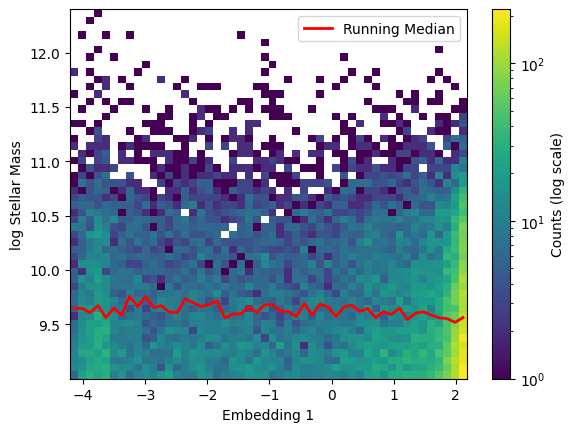

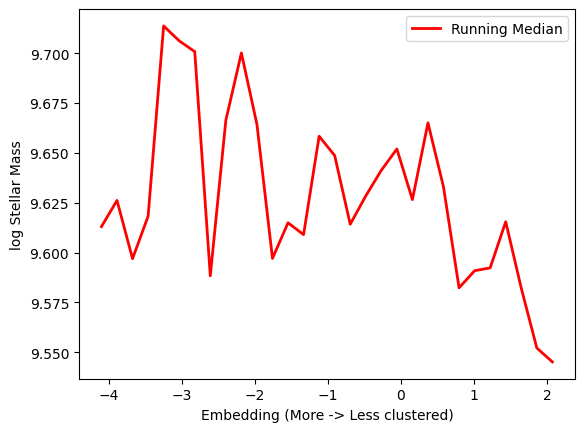

In [285]:
from scipy.stats import binned_statistic

x = embedding[:,0]
y = np.log10(subhalos['SubhaloMassType'][:,4]*1e10)

plt.hist2d(x, y, bins=50, norm=mpl.colors.LogNorm())
plt.xlabel("Embedding 1")
plt.ylabel("log Stellar Mass")
plt.colorbar(label='Counts (log scale)')

# Compute running median
bin_means, bin_edges, _ = binned_statistic(x, y, statistic='median', bins=50)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, bin_means, color='red', lw=2, label='Running Median')

plt.legend()
plt.show()

bin_means, bin_edges, _ = binned_statistic(x, y, statistic='median', bins=30)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, bin_means, color='red', lw=2, label='Running Median')
plt.xlabel("Embedding (More -> Less clustered)")
plt.ylabel("log Stellar Mass")
plt.legend()
plt.show()

In [310]:
sum(subhalos['SubhaloSFR'] == 0) / len(subhalos['SubhaloSFR'])

0.20265743001533132

In [354]:
mass = subhalos['SubhaloMassType'][:,4]*1e10
sum((np.log10(mass) > 10.5) & (np.log10(mass) < 11.5))

1786

(25118864315.09582, 316227766016.83795)

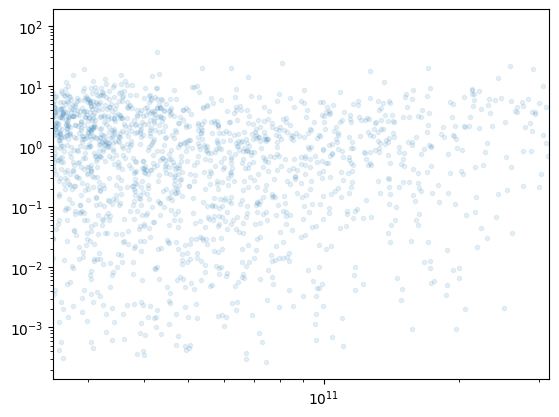

In [358]:
plt.plot(subhalos['SubhaloMassType'][:,4]*1e10, subhalos['SubhaloSFR'], '.', alpha=0.1)
plt.yscale('log')
plt.xscale('log')
plt.xlim(10**10.4, 10**11.5)

(array([5.213e+03, 1.651e+03, 1.680e+03, 1.375e+03, 1.071e+03, 8.060e+02,
        6.840e+02, 5.760e+02, 4.710e+02, 3.870e+02, 3.380e+02, 3.060e+02,
        2.450e+02, 2.320e+02, 1.790e+02, 2.090e+02, 1.670e+02, 1.360e+02,
        1.360e+02, 1.320e+02, 1.050e+02, 8.000e+01, 9.300e+01, 8.800e+01,
        7.100e+01, 9.000e+01, 7.900e+01, 7.200e+01, 4.800e+01, 5.600e+01,
        5.400e+01, 5.500e+01, 3.300e+01, 3.700e+01, 2.300e+01, 4.200e+01,
        3.100e+01, 2.500e+01, 2.400e+01, 2.600e+01, 2.700e+01, 1.900e+01,
        2.100e+01, 2.700e+01, 2.400e+01, 1.800e+01, 1.300e+01, 1.400e+01,
        9.000e+00, 1.500e+01, 1.300e+01, 9.000e+00, 7.000e+00, 8.000e+00,
        1.500e+01, 1.100e+01, 6.000e+00, 1.400e+01, 1.300e+01, 7.000e+00,
        9.000e+00, 7.000e+00, 6.000e+00, 1.100e+01, 4.000e+00, 1.000e+01,
        8.000e+00, 7.000e+00, 5.000e+00, 5.000e+00, 4.000e+00, 4.000e+00,
        4.000e+00, 1.000e+00, 3.000e+00, 7.000e+00, 0.000e+00, 6.000e+00,
        0.000e+00, 2.000e+00, 4.000e+0

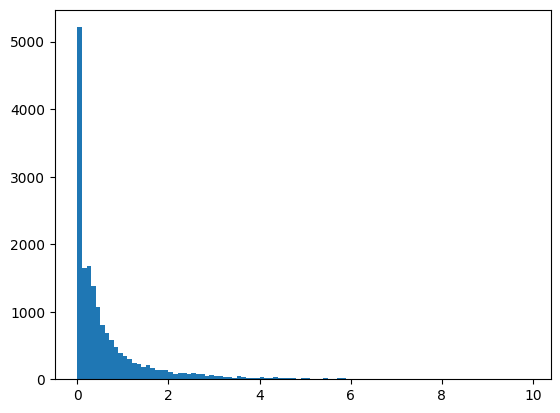

In [336]:
mask = subhalos['SubhaloSFR'] >= 0
plt.hist(subhalos['SubhaloSFR'][mask], bins=np.arange(0, 10, 0.1))


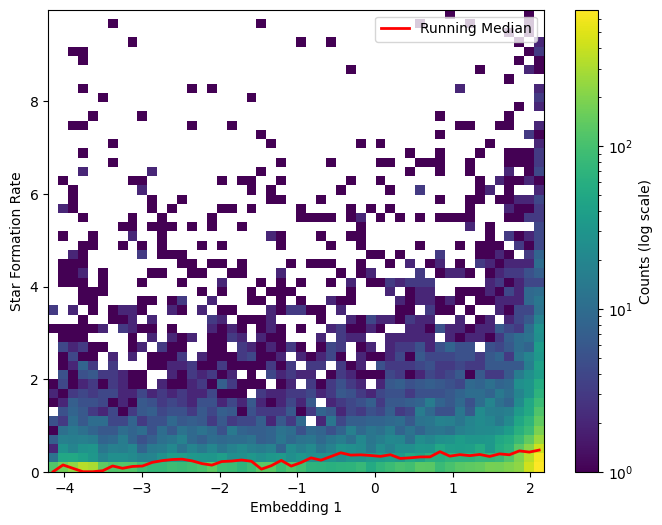

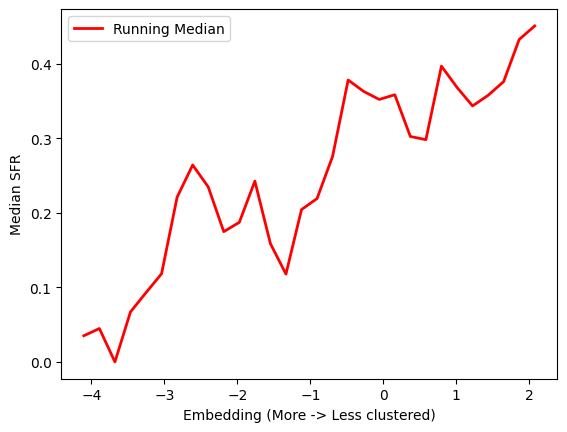

In [382]:
# Mask for SFR between 0 and 10

x = embedding[:,0]
y = subhalos['SubhaloSFR']

# mask_range = (y > 0.01) & (y < 10)
mask_range = (y >= 0) & (y < 10)


plt.figure(figsize=(8,6))
h = plt.hist2d(x[mask_range], y[mask_range], bins=50, norm=mpl.colors.LogNorm())
plt.xlabel("Embedding 1")
plt.ylabel("Star Formation Rate")
plt.colorbar(label='Counts (log scale)')

# Compute and plot running median on top of histogram
bin_means, bin_edges, _ = binned_statistic(x[mask_range], y[mask_range], statistic='median', bins=50)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, bin_means, color='red', lw=2, label='Running Median')
plt.legend()
plt.show()

# Separate plot: running median of log10(SFR) over embedding
# plt.figure(figsize=(8,4))
bin_means, bin_edges, _ = binned_statistic(x[mask_range], y[mask_range], statistic='median', bins=30)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, bin_means, color='red', lw=2, label='Running Median')
plt.xlabel("Embedding (More -> Less clustered)")
plt.ylabel("Median SFR")
plt.legend()
plt.show()


/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_91217/349380143.py:5: RuntimeWarning:

invalid value encountered in divide



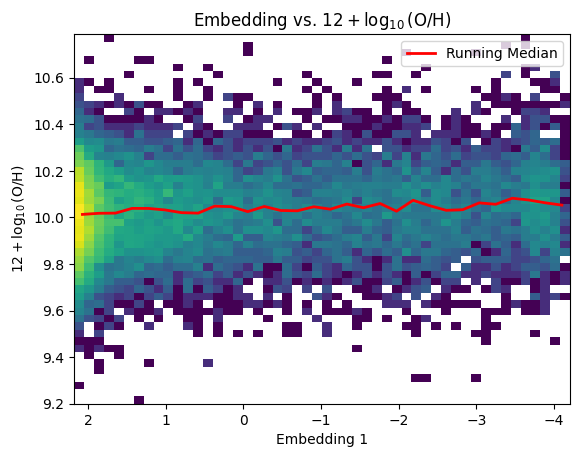

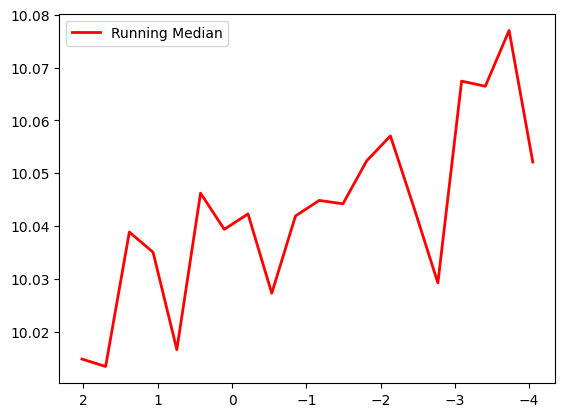

In [276]:
from scipy.stats import binned_statistic

# Calculate 12 + log10(O/H) for each subhalo
# O/H = SubhaloGasMetalFractions[:, 4] / SubhaloGasMetalFractions[:, 0]
O_H = subhalos['SubhaloGasMetalFractions'][:, 4] / subhalos['SubhaloGasMetalFractions'][:, 0]
twelve_plus_logOH = 12 + np.log10(O_H)
mask = ~np.isnan(twelve_plus_logOH)

plt.hist2d(embedding[mask,0], twelve_plus_logOH[mask], bins=50, norm=mpl.colors.LogNorm())
plt.xlabel("Embedding 1")
plt.ylabel(r"$12 + \log_{10}(\mathrm{O}/\mathrm{H})$")
plt.title(r"Embedding vs. $12 + \log_{10}(\mathrm{O}/\mathrm{H})$")

# Running average (median) line
mask = ~np.isnan(twelve_plus_logOH)
bin_means, bin_edges, _ = binned_statistic(embedding[:,0][mask], twelve_plus_logOH[mask], statistic='median', bins=30)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, bin_means, color='red', lw=2, label='Running Median')
# plt.ylim(10, 10.1)
plt.gca().invert_xaxis()
plt.legend()
plt.show()

bin_means, bin_edges, _ = binned_statistic(embedding[:,0][mask], twelve_plus_logOH[mask], statistic='median', bins=20)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, bin_means, color='red', lw=2, label='Running Median')
# plt.ylim(10, 10.1)
plt.gca().invert_xaxis()
plt.legend()
plt.show()

/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_91217/1873384520.py:3: RuntimeWarning:

invalid value encountered in divide



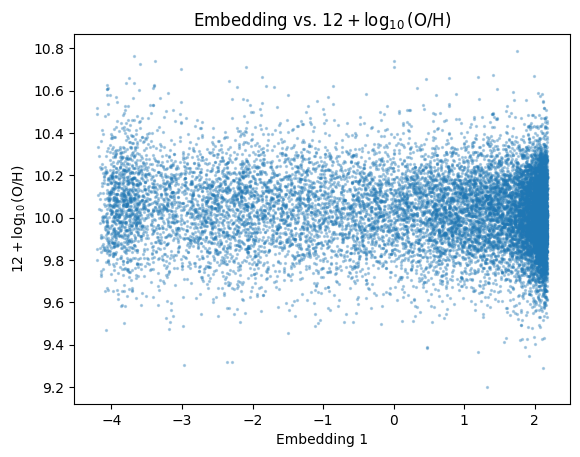

In [ ]:
from scipy.stats import binned_statistic

# Calculate 12 + log10(O/H) for each subhalo
# O/H = SubhaloGasMetalFractions[:, 4] / SubhaloGasMetalFractions[:, 0]
O_H = subhalos['SubhaloGasMetalFractions'][:, 4] / subhalos['SubhaloGasMetalFractions'][:, 0]
twelve_plus_logOH = 12 + np.log10(O_H)

# plt.scatter(embedding[:,0], twelve_plus_logOH, s=2, alpha=0.3)
# plt.xlabel("Embedding 1")
# plt.ylabel(r"$12 + \log_{10}(\mathrm{O}/\mathrm{H})$")
# plt.title(r"Embedding vs. $12 + \log_{10}(\mathrm{O}/\mathrm{H})$")

# # Running average (median) line
# mask = ~np.isnan(twelve_plus_logOH)
# bin_means, bin_edges, _ = binned_statistic(embedding[:,0][mask], twelve_plus_logOH[mask], statistic='median', bins=50)
# bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
# print(bin_centers, bin_means)
# plt.plot(bin_centers, bin_means, color='red', lw=2, label='Running Median')

plt.legend()
plt.show()

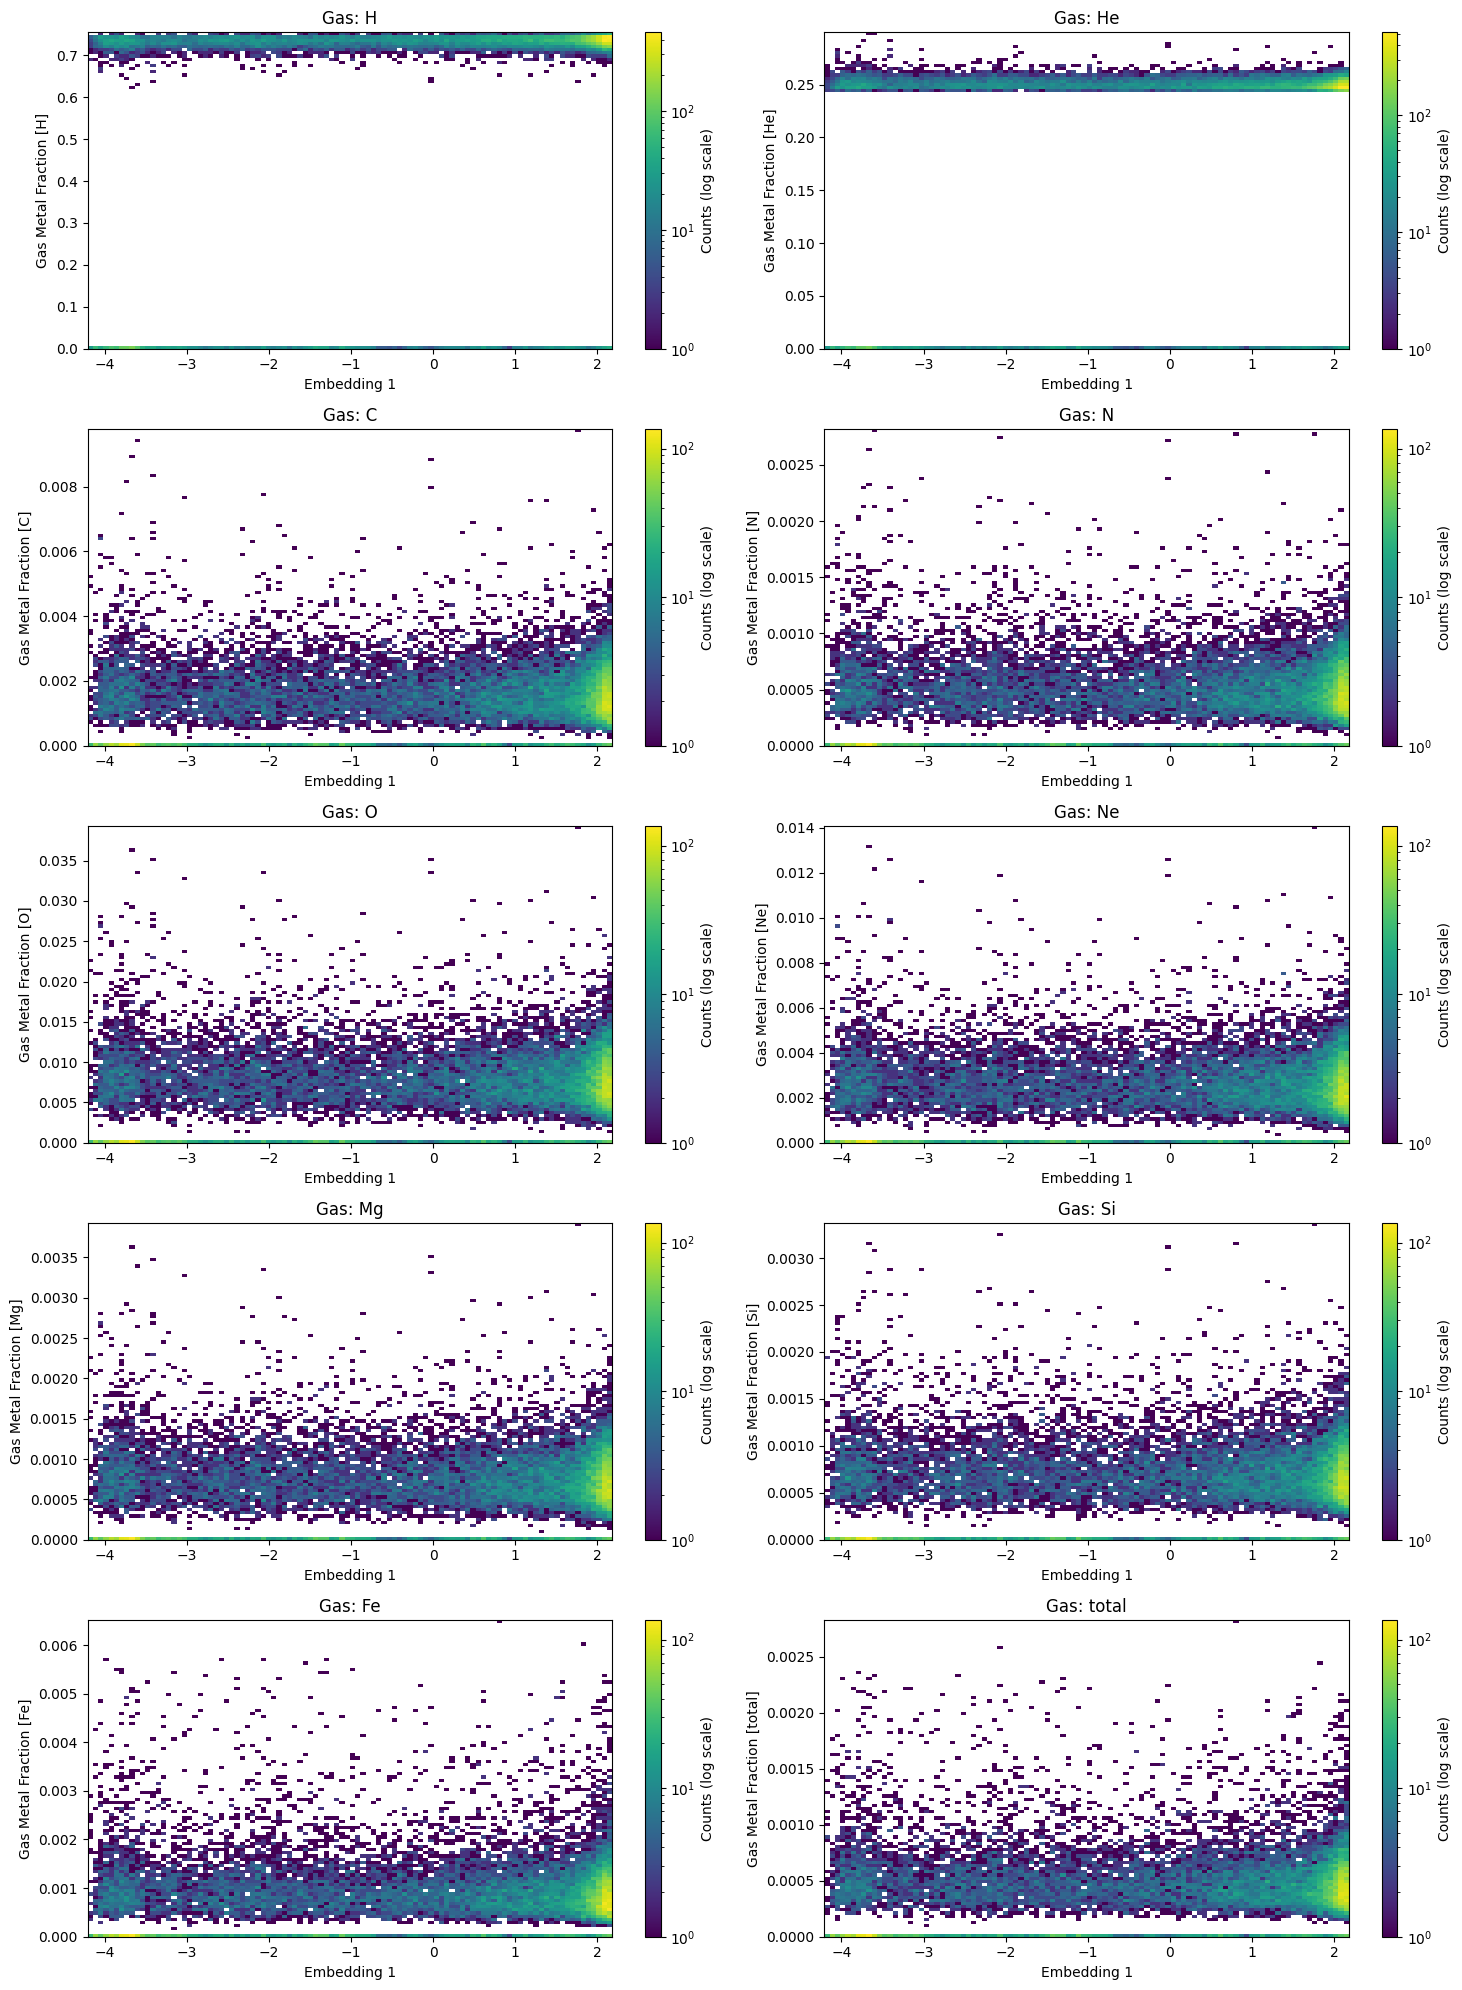

In [216]:
gases = ['H', 'He', 'C', 'N', 'O', 'Ne', 'Mg', 'Si', 'Fe', 'total']

plt.figure(figsize=(15, 20))
for i, gas in enumerate(gases):
    plt.subplot(5, 2, i+1)
    plt.hist2d(
        embedding[:,0],
        subhalos['SubhaloGasMetalFractions'][:,i],
        norm=mpl.colors.LogNorm(), bins=100
    )
    plt.xlabel("Embedding 1")
    plt.ylabel(f"Gas Metal Fraction [{gas}]")
    plt.colorbar(label='Counts (log scale)')
    plt.title(f"Gas: {gas}")

plt.tight_layout()
plt.show()

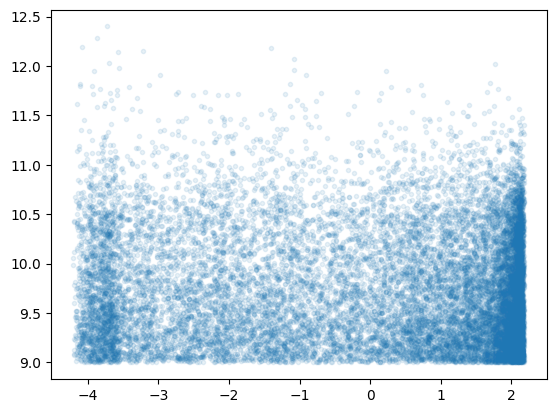

In [64]:
plt.plot(embedding[:,0], np.log10(subhalos['SubhaloMassType'][:,4]*1e10), '.', alpha=0.1)


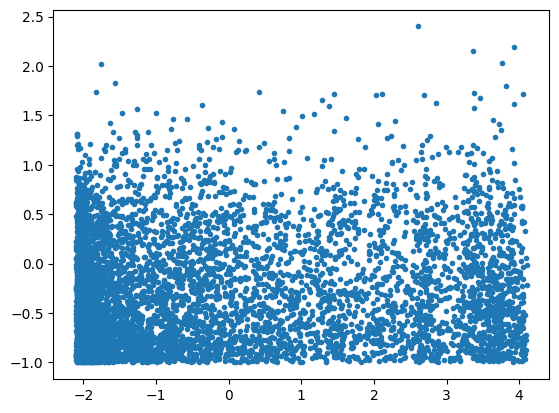

In [66]:
plt.plot(embedding[:,0], np.log10(subhalos['SubhaloMassType'][:,4]), '.')

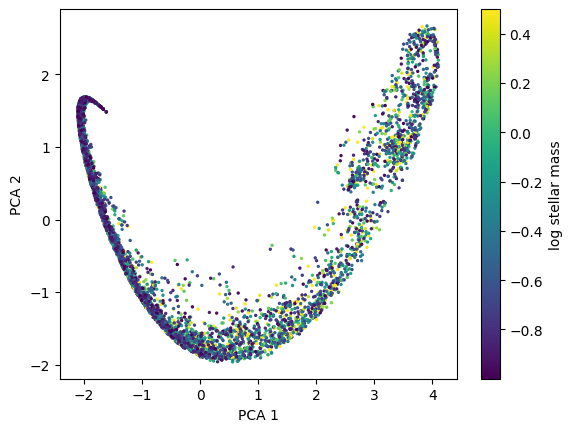

In [64]:
plt.scatter(embedding[:,0], embedding[:,1], c =np.log10(subhalos['SubhaloMassType'][:,4]),s=2, vmax=0.5)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="log stellar mass")
plt.show()

In [368]:
import numpy as np
from scipy.spatial import cKDTree

# from geometry_functions.coordinate_functions import get_proj_dist


from collections import defaultdict


############################################
# FINDING groupS WITH UNION-FIND
############################################
class Node:
    def __init__(self, key):
        self.key = key
        self.parent = self
        self.size = 1

class UnionFind(dict):
    def find(self, key):
        node = self.get(key, None)
        if node is None:
            node = self[key] = Node(key)
        else:
            while node.parent != node: 
                # walk up & perform path compression
                node.parent, node = node.parent.parent, node.parent
        return node

    def union(self, key_a, key_b):
        node_a = self.find(key_a)
        node_b = self.find(key_b)
        if node_a != node_b:  # disjoint? -> join!
            if node_a.size < node_b.size:
                node_a.parent = node_b
                node_b.size += node_a.size
            else:
                node_b.parent = node_a
                node_a.size += node_b.size
                
def find_components(line_iterator, max_size):
    forest = UnionFind()

    for line in line_iterator:
        forest.union(*line.split())

    result = defaultdict(list)
    for key in forest.keys():
        root = forest.find(key)
        if root.size <= max_size:
            result[root.key].append(int(float(key)))  # Convert key to float and then to int

    # return list of integers
    return list(result.values())

def find_groups_UnionFind(points, max_pair_sep, boxsize, max_n=10, poo=np.asarray([0, 0, 0])):
    '''assumes LOS is along z-axis and observer at poo (default origin)'''
    points -= poo  # shift points to observer at origin
    # find nearest neighbor for each galaxy
    tree = cKDTree(points, boxsize)
    # max_pair_sep = np.sqrt(transverse_max**2 + los_max**2)
    dd, ii = tree.query(points, distance_upper_bound=max_pair_sep, k=2) 

    # only keep indices where neighbor exists
    ii = ii[ii[:,1] < len(points)]
    
    # # remove pairs that are too far away
    # transverse_seps = np.abs(get_proj_dist(points[ii[:,1]], points[ii[:,0]]))
    # los_dist = np.sqrt(np.sum(points**2, axis=1))
    # los_seps = np.abs(los_dist[ii[:,1]] - los_dist[ii[:,0]])
    # to_remove = (transverse_seps > transverse_max) | (los_seps > los_max)
    # if transverse_min is not None:
    #     to_remove |= (transverse_seps < transverse_min)
 
    #to_remove[:,:1]=False # don't want to remove indices of centers
    # ii = ii[~to_remove]  # where the pairs are too close, functionally remove them from the list of pairs
    
    # find groups
    group_results = find_components([' '.join(map(str, row)) for row in ii], max_n)
    
    return group_results

In [369]:
subhalos['SubhaloPos']

array([[ 0.8490915 , 26.326998  , 18.306934  ],
       [ 0.10647334, 24.633324  , 16.900553  ],
       [ 0.8531124 , 26.72575   , 17.510681  ],
       ...,
       [36.158207  , 74.77495   , 70.913055  ],
       [23.255453  , 67.40363   , 73.68266   ],
       [45.46694   , 36.893852  , 72.4918    ]], dtype=float32)

In [370]:
threshold

5

In [375]:
groups = find_groups_UnionFind(subhalos['SubhaloPos'], max_pair_sep = 2, boxsize = 75, max_n = 1000)
group_lengths = np.array([len(group) for group in groups])

In [378]:
np.savetxt("tng50_positions.txt", subhalos['SubhaloPos'])

In [379]:
np.loadtxt("tng50_positions.txt")

array([[ 0.84909147, 26.32699776, 18.30693436],
       [ 0.10647334, 24.63332367, 16.90055275],
       [ 0.8531124 , 26.72574997, 17.51068115],
       ...,
       [36.15820694, 74.77494812, 70.91305542],
       [23.25545311, 67.40363312, 73.68266296],
       [45.46694183, 36.89385223, 72.4917984 ]])

Text(0, 0.5, 'Number of Groups')

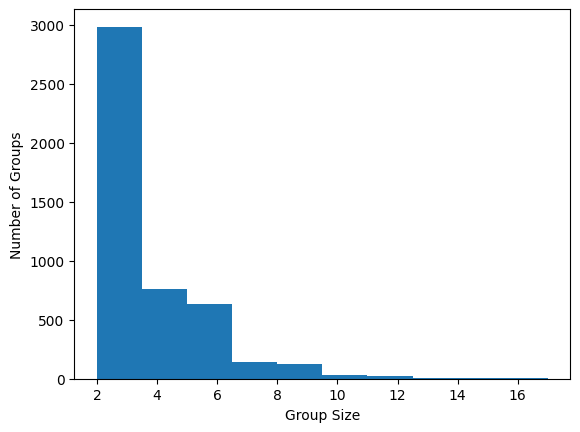

In [376]:
plt.hist(group_lengths)
plt.xlabel("Group Size")
plt.ylabel("Number of Groups")

In [377]:
sum(group_lengths > 10)

36

In [365]:
from itertools import chain

groups_with_more_than_10 = [group for group in groups if len(group) > 10]
groups_with_more_than_10_flat = list(chain.from_iterable(groups_with_more_than_10))


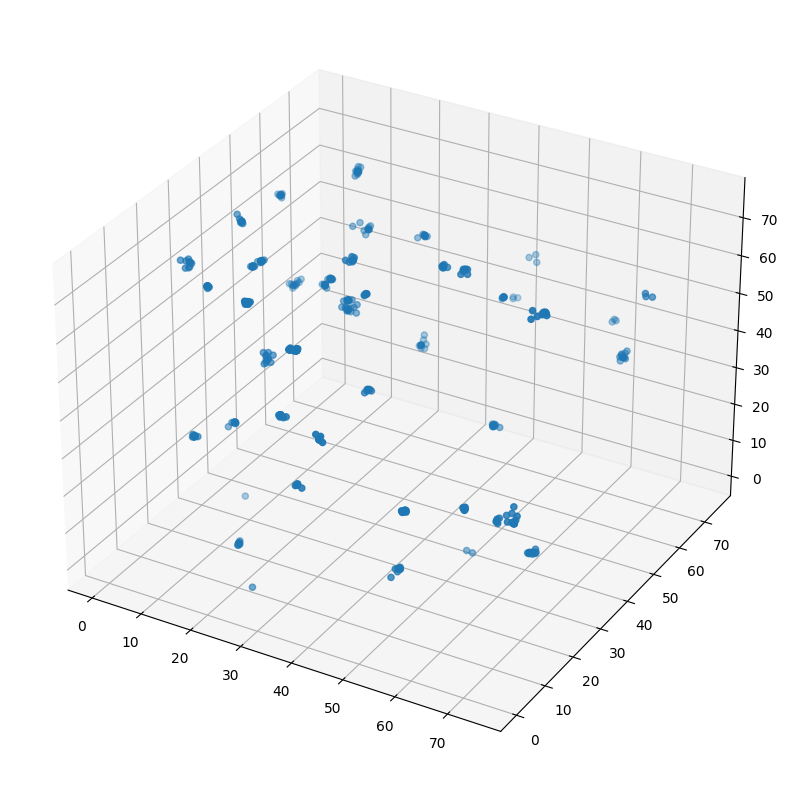

In [366]:
# Visualize embedding
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(subhalos['SubhaloPos'][groups_with_more_than_10_flat,0], subhalos['SubhaloPos'][groups_with_more_than_10_flat,1], subhalos['SubhaloPos'][groups_with_more_than_10_flat,2])
# p = ax.scatter(subhalos['SubhaloPos'][:,0], subhalos['SubhaloPos'][:,1], subhalos['SubhaloPos'][:,2], alpha=0.2)

# cbar = fig.colorbar(p, ax=ax)
# cbar.set_label("MDS Embedding")
plt.show()

In [367]:
from sklearn.cluster import DBSCAN

def detect_clusters(points, eps=1.0, min_samples=5):
    """
    Detect clusters in a 3D distribution of points using DBSCAN.

    Parameters:
        points (np.ndarray): Array of shape (N, 3) with 3D coordinates.
        eps (float): The maximum distance between two samples for them to be considered as in the same neighborhood.
        min_samples (int): The number of samples in a neighborhood for a point to be considered as a core point.

    Returns:
        labels (np.ndarray): Cluster labels for each point. Noise is labeled as -1.
    """
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
    return clustering.labels_

In [148]:
clustering = DBSCAN(eps=threshold, min_samples=50).fit(subhalos['SubhaloPos'])


In [149]:
np.unique(clustering.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20])

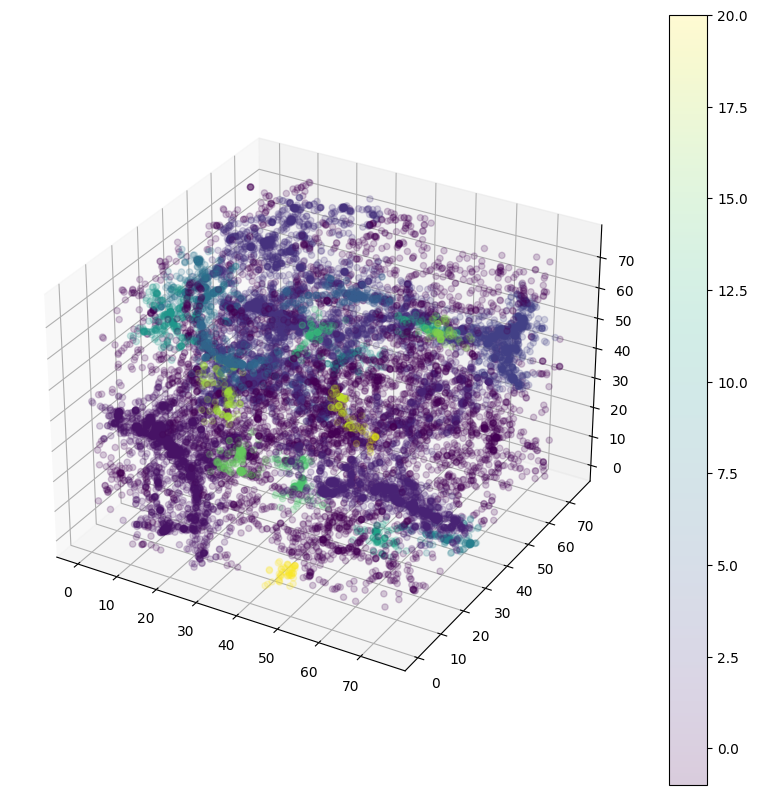

In [150]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(subhalos['SubhaloPos'][:,0], subhalos['SubhaloPos'][:,1], subhalos['SubhaloPos'][:,2], alpha=0.2, c=clustering.labels_, cmap='viridis')

cbar = fig.colorbar(p, ax=ax)
# cbar.set_label("MDS Embedding")
plt.show()

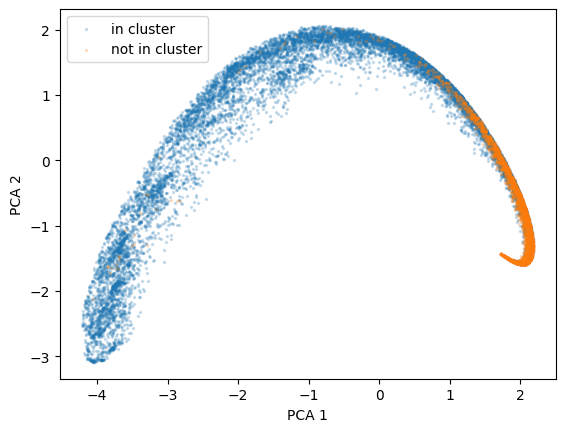

In [158]:
plt.scatter(embedding[clustering.labels_ >= 0,0], embedding[clustering.labels_ >= 0,1], s=2, alpha = 0.2, label="in cluster")
plt.scatter(embedding[clustering.labels_ < 0,0], embedding[clustering.labels_ < 0,1], s=2, alpha = 0.2, label="not in cluster")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
# plt.colorbar(label="Cluster Labels")
plt.legend()
plt.show()

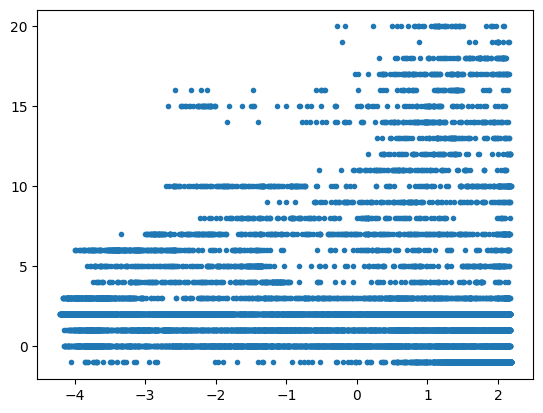

In [152]:
plt.plot(embedding[:,0], clustering.labels_, '.')